In [12]:
import pandas as pd
import numpy as np
np.random.seed(123)
n_sample=1000
class_0=0.9
n_class_0=int(n_sample*class_0)
n_class_1=n_sample-n_class_0


In [17]:
n_class_0,n_sample

(900, 1000)

In [18]:
class_0=pd.DataFrame({
    'f1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'f2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'tar':[0]*n_class_0
})
class_1=pd.DataFrame({
    'f1':np.random.normal(loc=0,scale=1,size=n_class_1),
    'f2':np.random.normal(loc=0,scale=1,size=n_class_1),
    'tar':[1]*n_class_1
})

In [19]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)


In [20]:
df.tail()

,f1,f2,tar
995,0.677156,-0.907952,1
996,0.963404,-1.818045,1
997,-0.378524,-0.122733,1
998,1.429559,1.794486,1
999,1.532273,-0.320510,1


In [21]:
df['tar'].value_counts()

tar
0    900
1    100
Name: count, dtype: int64

In [22]:
#upsampling
df_minor=df[df['tar']==1]
df_major=df[df['tar']==0]

In [24]:
from sklearn.utils import resample
df_minor_up=resample(df_minor,replace=True,
n_samples=len(df_major),
random_state=42
)

In [25]:
df_minor_up.head()

,f1,f2,tar
951,0.905343,-0.504849,1
992,0.000977,-0.185167,1
914,-0.072043,0.280911,1
971,0.819483,0.964646,1
960,0.456515,-0.166472,1


In [26]:
df_up=pd.concat([df_major,df_minor_up])


In [27]:
df_up['tar'].value_counts()

tar
0    900
1    900
Name: count, dtype: int64

In [28]:
#Down sampling

In [ ]:
import pandas as pd
import numpy as np
np.random.seed(123)
n_sample=1000
class_0=0.9
n_class_0=int(n_sample*class_0)
n_class_1=n_sample-n_class_0
class_0=pd.DataFrame({
    'f1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'f2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'tar':[0]*n_class_0
})
class_1=pd.DataFrame({
    'f1':np.random.normal(loc=0,scale=1,size=n_class_1),
    'f2':np.random.normal(loc=0,scale=1,size=n_class_1),
    'tar':[1]*n_class_1
})

In [29]:
#downsampling
df_minor=df[df['tar']==1]
df_major=df[df['tar']==0]

In [31]:
from sklearn.utils import resample
df_major_dn=resample(df_major,replace=False,
n_samples=len(df_minor),
random_state=42
)

In [33]:
df_major_dn.shape

(100, 3)

In [34]:
df_dn=pd.concat([df_minor,df_major_dn])

In [38]:
df_dn['tar'].value_counts()

tar
1    100
0    100
Name: count, dtype: int64

upsampling technique
 SMOTE(synthetic minority up sampling oversampling technique.)
Smote is a technique used in machine learning to address imbalanced data set where the minority

class has significantly fewer instances than the majority class.

Smote involves generating synthetic instances of the minority class by interpolating between the existing

instances.

interpolating techniques
creating own data
 



In [39]:
from sklearn.datasets import make_classification


In [42]:
x,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.9],random_state=42)

In [45]:
import pandas as pd
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,1.073546,-1.101339,0
1,0.755945,-1.172352,0
2,1.354479,-0.948528,0
3,3.103090,0.233485,0
4,1.951888,-0.270157,0


In [46]:
final_df['target'].value_counts()

target
0    896
1    104
Name: count, dtype: int64

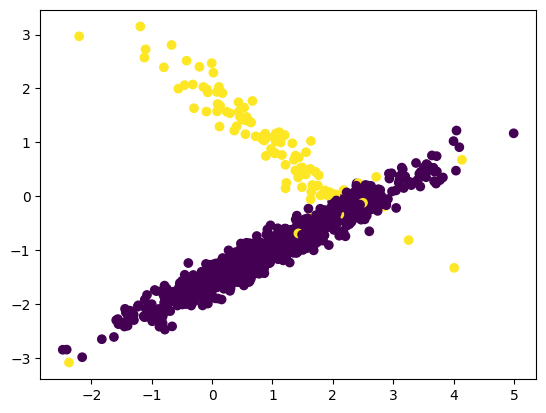

In [68]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [ ]:
%pip install imblearn


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
from imblearn.over_sampling import SMOTE

In [71]:
#transform the dataset
oversample=SMOTE()
x,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [72]:
x.shape

(1792, 2)

In [73]:
y.shape

(1792,)

In [74]:
len(y[y==0])

896

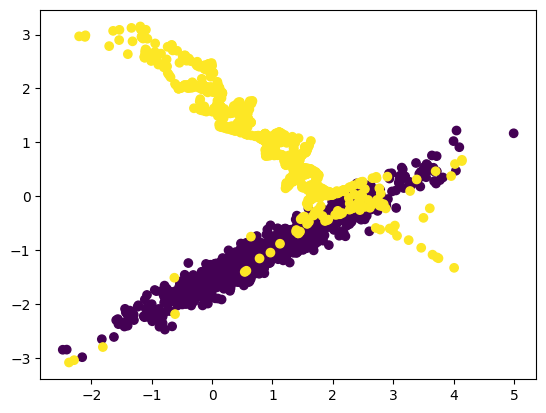

In [76]:
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])